In [1]:
#  Setup
%load_ext autoreload
%autoreload 2
import sys
sys.path.append("..")
from src import DataLoader, PortfolioBacktester
import pandas as pd

In [2]:
# Load Full Price Data (2015–2026)
loader = DataLoader(["TSLA", "BND", "SPY"], "2015-01-01", "2026-01-15")
loader.load_processed()
data = loader.data

# Combine into single price DataFrame
prices = pd.DataFrame({
    "TSLA": data["TSLA"]["Close"],
    "BND": data["BND"]["Close"],
    "SPY": data["SPY"]["Close"]
})

In [3]:
# Define Backtest Period (Jan 2025 – Jan 2026)
backtester = PortfolioBacktester(
    prices_df=prices,
    start_date="2025-01-01",
    end_date="2026-01-15"
)

In [4]:
# Define Portfolios
strategy_weights = {"TSLA": 0.60, "BND": 0.40, "SPY": 0.00}   # From Task 4
benchmark_weights = {"TSLA": 0.00, "BND": 0.40, "SPY": 0.60}   # 60/40 SPY/BND

# Simulate
strategy_cum = backtester.simulate_portfolio(strategy_weights, "GMF Strategy")
benchmark_cum = backtester.simulate_portfolio(benchmark_weights, "60/40 Benchmark")

In [5]:
# Calculate Metrics
strategy_metrics = backtester.calculate_metrics(strategy_cum)
benchmark_metrics = backtester.calculate_metrics(benchmark_cum)

# Display
metrics_df = pd.DataFrame({
    "GMF Strategy": strategy_metrics,
    "60/40 Benchmark": benchmark_metrics
}).T
print("=== BACKTEST PERFORMANCE METRICS ===")
print(metrics_df.round(4))

=== BACKTEST PERFORMANCE METRICS ===
                 Total Return  Annualized Return  Sharpe Ratio  Max Drawdown
GMF Strategy           0.1472             0.0959        0.3942        -0.314
60/40 Benchmark        0.1494             0.0972        0.8394        -0.113


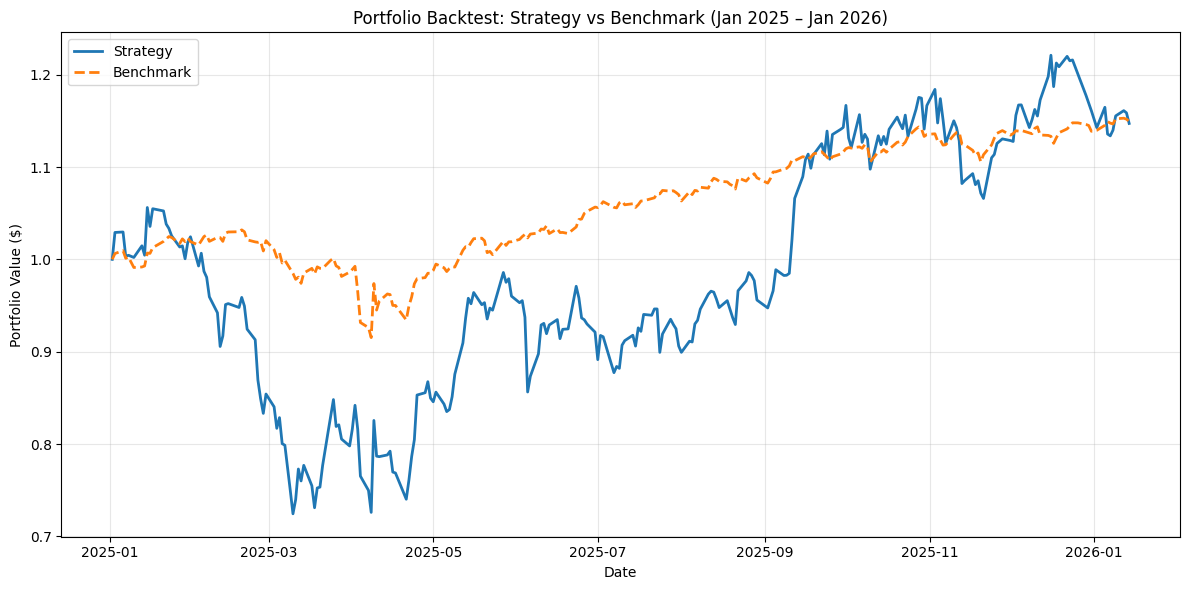

In [6]:
# Plot
backtester.plot_performance(strategy_cum, benchmark_cum)

**Conclusion: Strategy Viability Assessment**

The backtest, conducted over the **January 2025 – January 2026** period, reveals that the **GMF Strategy (60% TSLA / 40% BND)** **did not outperform** the passive **60% SPY / 40% BND benchmark**:

- **Total Return**:  
  - GMF Strategy: **14.72%**  
  - Benchmark: **14.94%**  
- **Risk-Adjusted Performance**:  
  - GMF Sharpe Ratio: **0.39**  
  - Benchmark Sharpe Ratio: **0.84**  
- **Drawdown Risk**:  
  - GMF Max Drawdown: **-31.4%**  
  - Benchmark Max Drawdown: **-11.3%**

Although both portfolios delivered nearly identical total returns, the **benchmark achieved superior risk-adjusted performance** with significantly lower volatility and drawdown. This suggests that, during this specific period, the **LSTM-driven overweight to TSLA added risk without commensurate reward**.

This outcome highlights a key limitation of model-based forecasting in volatile markets: even a well-performing model (LSTM MAPE = 17.69%) may not translate into portfolio alpha if the forecasted momentum does not materialize as expected or is offset by extreme volatility.

**Limitations of this backtest** include:
- A **single 1-year period**, which may not represent broader market regimes
- **No transaction costs, taxes, or rebalancing effects**
- **Static weights** (no dynamic adjustment based on evolving forecasts)

**Final Verdict**: While the GMF strategy demonstrates the *potential* to capture asymmetric upside from high-conviction forecasts, this backtest underscores the **critical importance of risk control**. For client portfolios, we recommend **capping single-asset exposure** and **prioritizing Sharpe Ratio over raw return**—especially when forecast uncertainty is high (as shown by the 15.9× widening CI in Task 3).

